<a href="https://colab.research.google.com/github/Shinyhunter95/Masters-Project/blob/main/AR(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

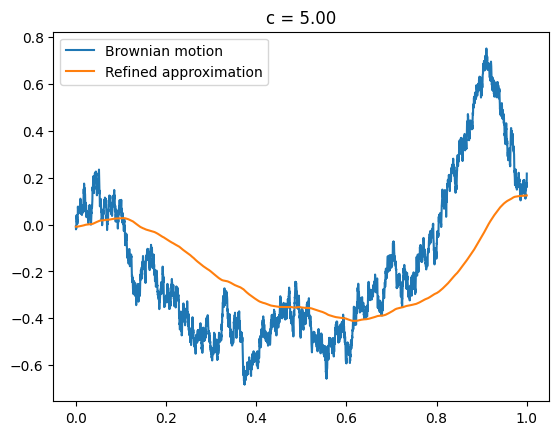

sup |W(t)| = 0.752000098201
sup |X(t)| = 0.41095599805694516
sup |W - X| = 0.7669084090281757
sup |OU term| 0.7669084090281757


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000

a = 5.0 # This determines c
rho = 1 - a/N

c = N * np.log(1/rho)

# time grid
t = np.linspace(0, 1, N)

# ---------------------------------
# Brownian motion
# ---------------------------------

np.random.seed(65535)

dt = 1/N
dW = np.sqrt(dt) * np.random.randn(N)
W = np.cumsum(dW)

# ---------------------------------
# OU correction term
# ---------------------------------

alpha = np.exp(-c * dt)

OU_term = np.zeros(N)

for k in range(1, N):
    OU_term[k] = alpha * OU_term[k-1] + dW[k]

# This is slower
# OU_term = np.zeros(N)

# for k in range(N):

#     tk = t[k]

#     kernel = np.exp(-c * (tk - t[:k+1]))

#     OU_term[k] = np.sum(kernel * dW[:k+1])

# ---------------------------------
# Approximation process
# ---------------------------------

X = W - OU_term

# ---------------------------------
# Plot
# ---------------------------------

plt.plot(t, W, label='Brownian motion')
plt.plot(t, X, label='Refined approximation')

plt.legend()
plt.title(f'c = {c:.2f}')
plt.show()

print("sup |W(t)| =", np.max(np.abs(W)))
print("sup |X(t)| =", np.max(np.abs(X)))

print("sup |W - X| =", np.max(np.abs(W - X)))
print("sup |OU term|", np.max(np.abs(OU_term)))

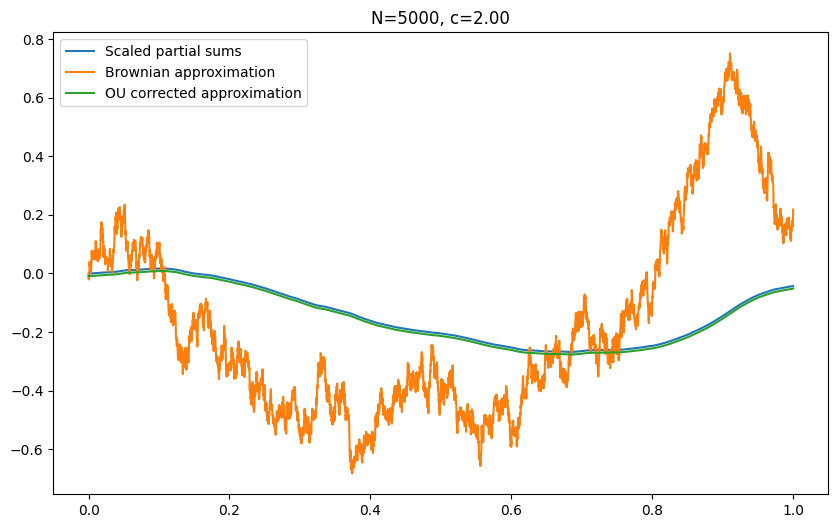

Z = W - Y
sup |Z - W|        = 0.8803802528969411
sup |Z - (W - Y))| = 0.009090387057456267
sup |Y|            = 0.8894706399543973


In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000

a = 2.0
rho = 1 - a / N

c = N * np.log(1 / rho)

dt = 1 / N
t = np.linspace(0, 1, N)

# ---------------------------------
# Random seed
# ---------------------------------

np.random.seed(65535)

# ---------------------------------
# Gaussian innovations
# ---------------------------------

eps = np.random.randn(N)

# ---------------------------------
# AR(1) process
# ---------------------------------

U = np.zeros(N)

for k in range(1, N):
    U[k] = rho * U[k-1] + eps[k]

# ---------------------------------
# Partial sums
# ---------------------------------

S = np.cumsum(U)

# normalized process:
# (1-rho) N^{-1/2} S(Nt)

Z = (1 - rho) * S / np.sqrt(N)

# ---------------------------------
# Brownian motion
# ---------------------------------

dW = eps / np.sqrt(N)

W = np.cumsum(dW)

# ---------------------------------
# OU correction term
# ---------------------------------

alpha = np.exp(-c * dt)

OU_term = np.zeros(N)

for k in range(1, N):
    OU_term[k] = alpha * OU_term[k-1] + dW[k]

# corrected approximation

W_corr = W - OU_term

# ---------------------------------
# Errors
# ---------------------------------

err_BM = np.max(np.abs(Z - W))

err_corr = np.max(np.abs(Z - W_corr))

# ---------------------------------
# Plot
# ---------------------------------

plt.figure(figsize=(10,6))

plt.plot(t, Z, label='Scaled partial sums')

plt.plot(t, W, label='Brownian approximation')

plt.plot(t, W_corr, label='OU corrected approximation')

plt.legend()

plt.title(f'N={N}, c={c:.2f}')
plt.show()

# ---------------------------------
# Diagnostics
# ---------------------------------

print("Z = W - Y")
print("sup |Z - W|        =", err_BM)
print("sup |Z - (W - Y))| =", err_corr)
print("sup |Y|            =", np.max(np.abs(OU_term)))

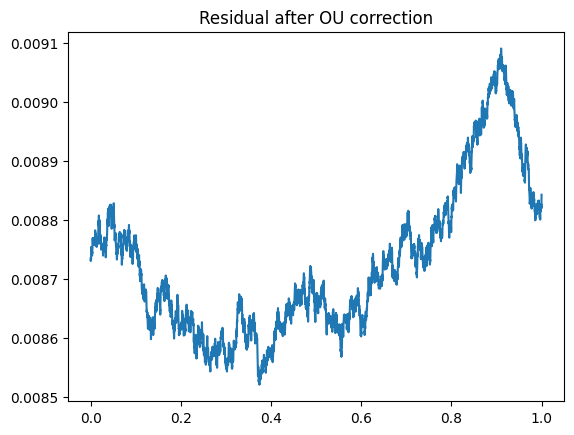

0.009090387057456267


In [55]:
residual = Z - (W - OU_term)

plt.plot(t, residual)
plt.title("Residual after OU correction")
plt.show()

# sup |Z - (W - Y))|
print(np.max(np.abs(residual)))

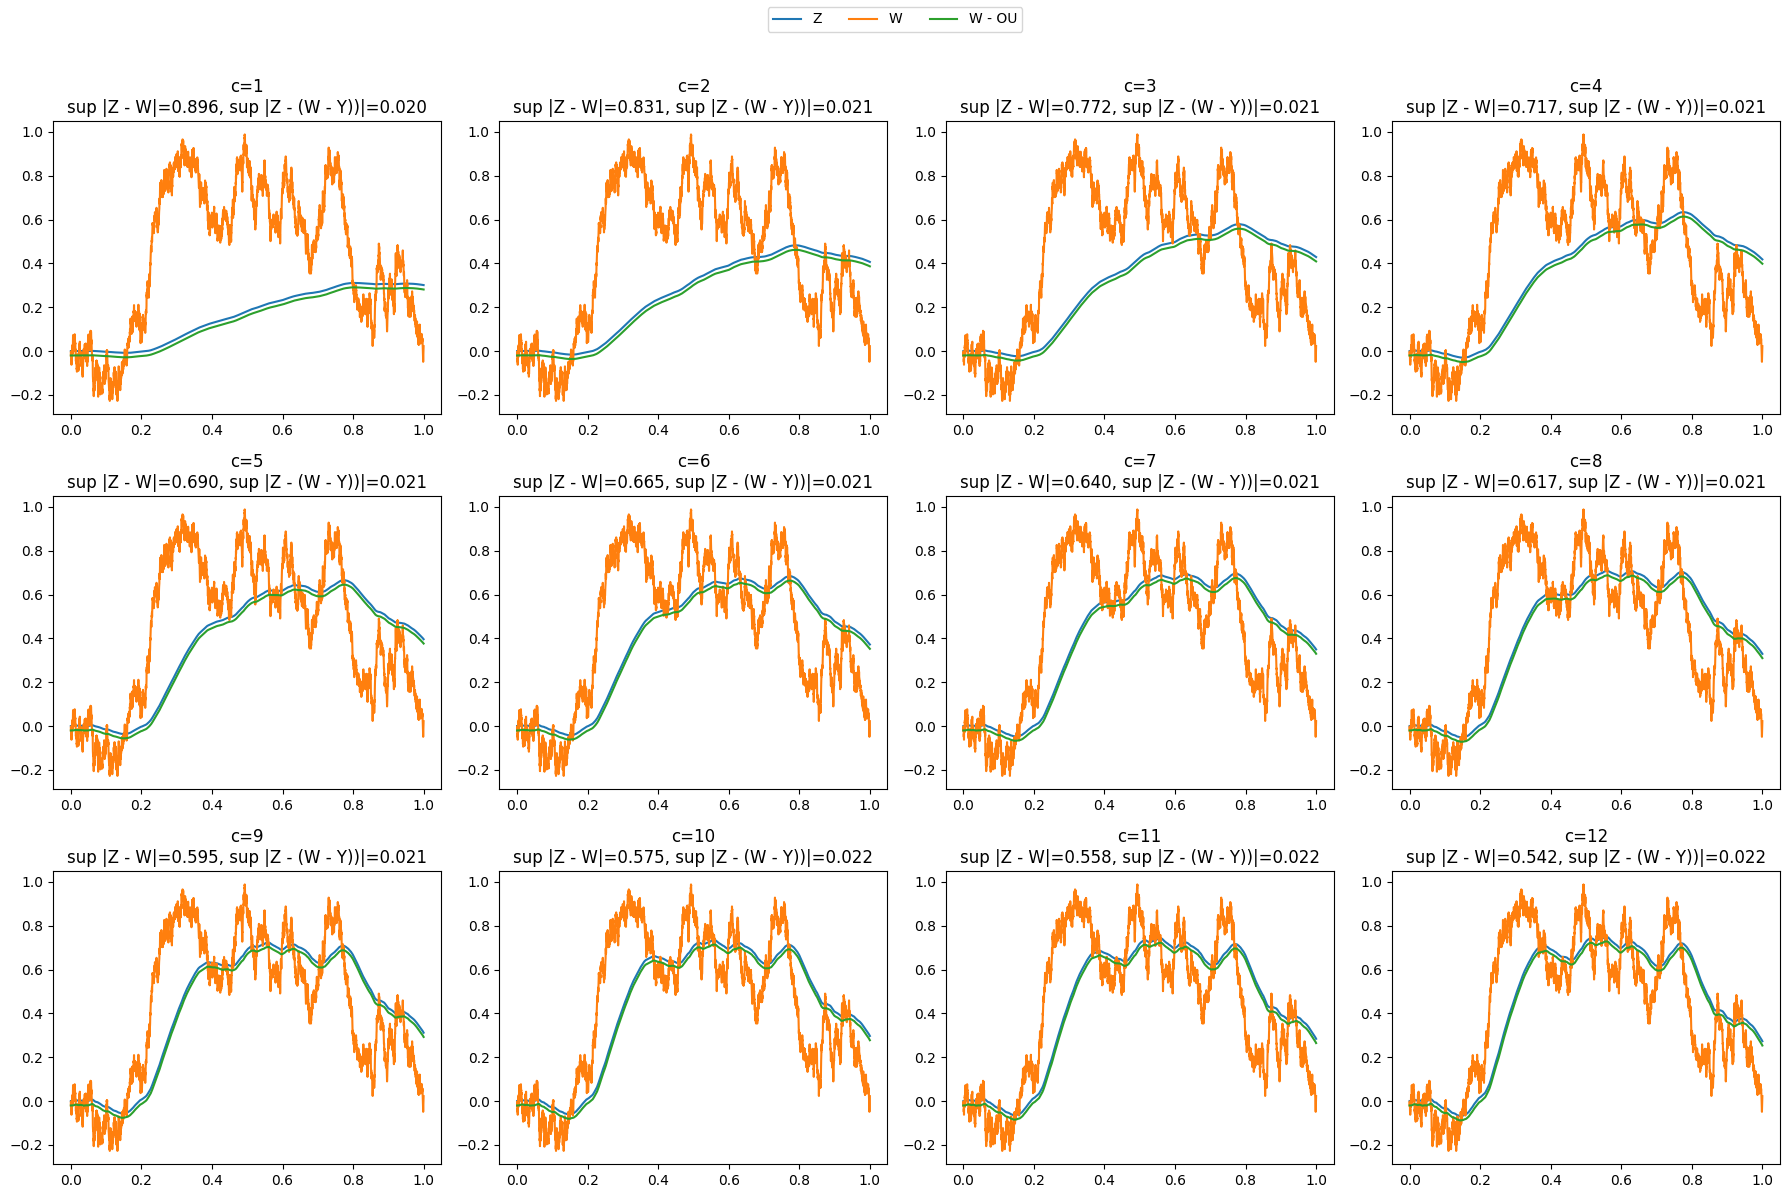

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000

dt = 1 / N
t = np.linspace(0, 1, N)

# ---------------------------------
# Random seed
# ---------------------------------

rng = np.random.default_rng(12345)

# Use the SAME innovations for every c
eps = rng.standard_normal(N)

# ---------------------------------
# Figure setup
# ---------------------------------

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

axes = axes.flatten()

# ---------------------------------
# Loop over c values
# ---------------------------------

for idx, c in enumerate(range(1, 13)):

    rho = 1 - c / N

    # ---------------------------------
    # AR(1) process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial sums
    # ---------------------------------

    S = np.cumsum(U)

    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian motion
    # ---------------------------------

    dW = eps / np.sqrt(N)

    W = np.cumsum(dW)

    # ---------------------------------
    # OU correction
    # ---------------------------------

    alpha = np.exp(-c * dt)

    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Errors
    # ---------------------------------

    err_BM = np.max(np.abs(Z - W))

    err_corr = np.max(np.abs(Z - W_corr))

    # ---------------------------------
    # Plot
    # ---------------------------------

    ax = axes[idx]

    ax.plot(t, Z, label='Z')
    ax.plot(t, W, label='W')
    ax.plot(t, W_corr, label='W - OU')

    ax.set_title(
        f'c={c}\n'
        f'sup |Z - W|={err_BM:.3f}, '
        f'sup |Z - (W - Y))|={err_corr:.3f}'
    )

# ---------------------------------
# Shared legend
# ---------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()